In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model    import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)


# (i)  READ DATASET INTO DATAFRAME

df = pd.read_csv('salary_prediction2.csv')
print("  Dataset Loaded")
print(df.to_string(index=False))
print(f"\n  Shape   : {df.shape}  (rows × columns)")
print(f"  Columns : {list(df.columns)}")
print("\n  Statistical Summary:")
print(df.describe().round(2))

# Features and target
features = ['experience', 'age', 'performance','education', 'projects', 'certifications']
X = df[features]
y = df['salary']

print(f"\n  Input Features : {features}")
print(f"  Target         : salary")

  Dataset Loaded
 experience  age  performance  education  projects  certifications  salary
          7   29           69          1         8               5  102585
         15   37           85          1        16               4  135407
         11   31           68          3        13               3  127771
          8   30           75          3        18               0  117404
          7   31           52          1        10               4   94560
         19   41           68          1        19               0  138200
         11   31           69          2        17               2  117690
         11   35           81          1        19               0  112570
          4   25           56          2         5               5   90129
          8   30           90          1         9               0  104732
          3   23           82          2        12               0   87853
          2   23           89          3         1               5  106514
        

In [2]:
# (ii)  SPLIT DATASET IN THREE RATIOS: 70:30 / 60:40 / 80:20
splits = {
    '70:30': train_test_split(X, y, test_size=0.30, random_state=42),
    '60:40': train_test_split(X, y, test_size=0.40, random_state=42),
    '80:20': train_test_split(X, y, test_size=0.20, random_state=42),
}

print("   Dataset Split Sizes")
print(f"  {'Ratio':<10} {'Train samples':<18} {'Test samples'}")
print("  " + "-" * 40)
for ratio, (Xtr, Xte, ytr, yte) in splits.items():
    print(f"  {ratio:<10} {len(Xtr):<18} {len(Xte)}")

   Dataset Split Sizes
  Ratio      Train samples      Test samples
  ----------------------------------------
  70:30      70                 30
  60:40      60                 40
  80:20      80                 20


In [9]:
# (iii) TRAIN MODEL on all three splits
print("   Model Training — Multiple Linear Regression")
models     = {}
results    = {}

for ratio, (X_train, X_test, y_train, y_test) in splits.items():
    m = LinearRegression()
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)

    models[ratio]  = (m, X_test, y_test, y_pred)
    results[ratio] = {
        'MAE' : mean_absolute_error(y_test, y_pred),
        'MSE' : mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2'  : r2_score(y_test, y_pred)
    }
    print(f"\n Trained on split {ratio}")

   Model Training — Multiple Linear Regression

 Trained on split 70:30

 Trained on split 60:40

 Trained on split 80:20


In [10]:
# (iv) COEFFICIENTS and INTERCEPT for each split
print(" Coefficients and Intercept")
for ratio, (m, X_test, y_test, y_pred) in models.items():
    print(f"\n  ── Split {ratio} ──")
    print(f"  {'Feature':<18} {'Coefficient':>15}")
    for feat, coef in zip(features, m.coef_):
        print(f"  {feat:<18} {coef:>15.4f}")
    print(f"  {'Intercept':<18} {m.intercept_:>15.4f}")

    print(f"\n  Regression Equation:")
    eq = " + ".join([f"({c:.1f} × {f})" for f, c in zip(features, m.coef_)])
    print(f"  salary = {eq}")
    print(f" + ({m.intercept_:.1f})")

 Coefficients and Intercept

  ── Split 70:30 ──
  Feature                Coefficient
  experience               3262.7838
  age                       203.4182
  performance               401.0676
  education                7716.4633
  projects                  203.5998
  certifications           1547.1895
  Intercept               27459.3401

  Regression Equation:
  salary = (3262.8 × experience) + (203.4 × age) + (401.1 × performance) + (7716.5 × education) + (203.6 × projects) + (1547.2 × certifications)
 + (27459.3)

  ── Split 60:40 ──
  Feature                Coefficient
  experience               3274.5145
  age                       190.3952
  performance               399.1699
  education                7682.4405
  projects                  175.2513
  certifications           1483.9045
  Intercept               28470.6618

  Regression Equation:
  salary = (3274.5 × experience) + (190.4 × age) + (399.2 × performance) + (7682.4 × education) + (175.3 × projects) + (1483.9 × cer

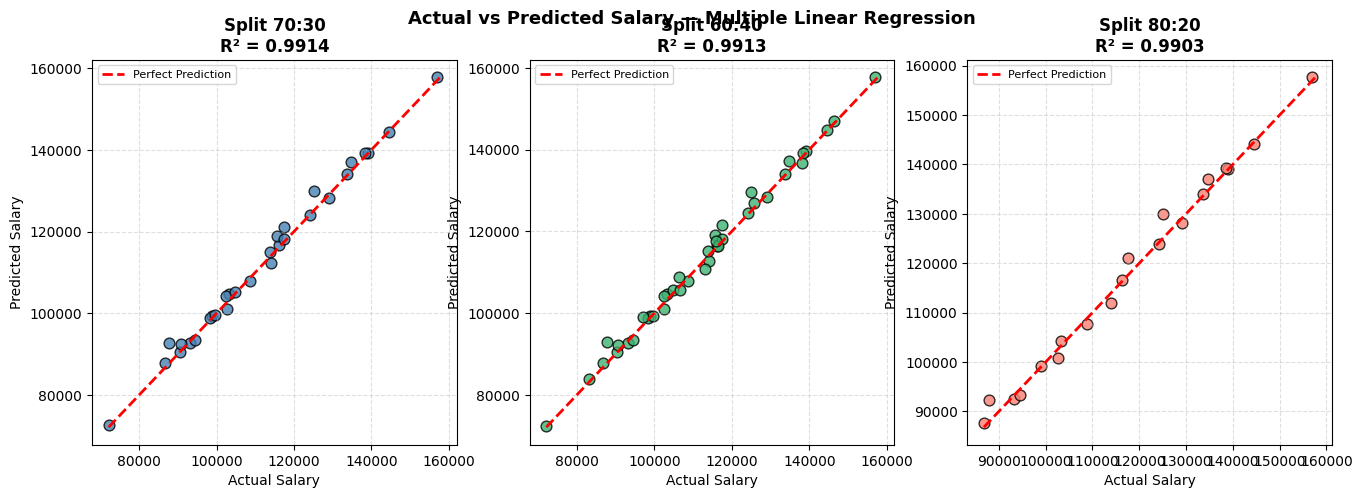

In [11]:
# (v)  PLOTS — Actual vs Predicted for all 3 splits
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Actual vs Predicted Salary — Multiple Linear Regression',fontsize=13, fontweight='bold')
colors = ['steelblue', 'mediumseagreen', 'salmon']

for ax, (ratio, (m, X_test, y_test, y_pred)), color in zip(axes, models.items(), colors):
    ax.scatter(y_test, y_pred, color=color, edgecolors='black', s=60, alpha=0.8)
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_title(f'Split {ratio}\nR² = {results[ratio]["R2"]:.4f}', fontweight='bold')
    ax.set_xlabel('Actual Salary')
    ax.set_ylabel('Predicted Salary')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

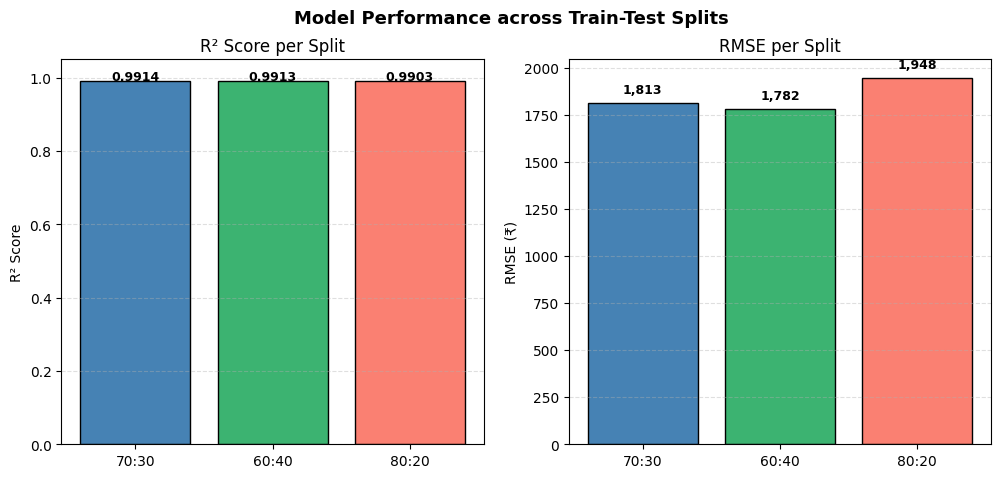

In [15]:
#  Bar chart comparing metrics across splits 
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Model Performance across Train-Test Splits',fontsize=13, fontweight='bold')

ratio_labels = list(results.keys())
r2_vals   = [results[r]['R2']   for r in ratio_labels]
rmse_vals = [results[r]['RMSE'] for r in ratio_labels]
bar_colors = ['steelblue', 'mediumseagreen', 'salmon']

bars1 = axes2[0].bar(ratio_labels, r2_vals, color=bar_colors, edgecolor='black')
for b, v in zip(bars1, r2_vals):
    axes2[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.002,f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
axes2[0].set_title('R² Score per Split')
axes2[0].set_ylabel('R² Score')
axes2[0].set_ylim(0, 1.05)
axes2[0].grid(axis='y', linestyle='--', alpha=0.4)

bars2 = axes2[1].bar(ratio_labels, rmse_vals, color=bar_colors, edgecolor='black')
for b, v in zip(bars2, rmse_vals):
    axes2[1].text(b.get_x()+b.get_width()/2, b.get_height()+50,f'{v:,.0f}', ha='center', fontweight='bold', fontsize=9)
axes2[1].set_title('RMSE per Split')
axes2[1].set_ylabel('RMSE (₹)')
axes2[1].grid(axis='y', linestyle='--', alpha=0.4)

In [16]:
# (vi)  PREDICT SALARY for new data entered by USER
print(" Predict Salary for New Employee")
# Use 70:30 model for prediction
best_model = models['70:30'][0]
print("  Enter details for the new employee:")
print("  (education: 1=UG, 2=PG, 3=PhD)\n")

try:
    exp   = float(input("  Years of Experience  : "))
    age   = float(input("  Age                  : "))
    perf  = float(input("  Performance Score    : "))
    edu   = float(input("  Education Level      : "))
    proj  = float(input("  Number of Projects   : "))
    certs = float(input("  Certifications       : "))

    new_emp = pd.DataFrame([[exp, age, perf, edu, proj, certs]],
                           columns=features)
    pred_sal = best_model.predict(new_emp)[0]

    print(f"\n   Predicted Salary : ₹ {pred_sal:,.2f}")

except Exception:
    # If running non-interactively, show a sample prediction
    sample = [[8, 30, 75, 2, 10, 3]]
    new_emp = pd.DataFrame(sample, columns=features)
    pred_sal = best_model.predict(new_emp)[0]
    print("  (Non-interactive mode — using sample values)")
    print(f"  Sample input : experience=8, age=30, performance=75,")
    print(f"  education=2, projects=10, certifications=3")
    print(f"  Predicted Salary : ₹ {pred_sal:,.2f}")

 Predict Salary for New Employee
  Enter details for the new employee:
  (education: 1=UG, 2=PG, 3=PhD)



  Years of Experience  :  4
  Age                  :  26
  Performance Score    :  39
  Education Level      :  2
  Number of Projects   :  3
  Certifications       :  1



   Predicted Salary : ₹ 79,031.90


In [17]:
# (vii)  EVALUATION METRICS for all splits
print("Model Evaluation Metrics")
print(f"\n  {'Metric':<8} {'70:30':>12} {'60:40':>12} {'80:20':>12}")

for metric in ['MAE', 'MSE', 'RMSE', 'R2']:
    vals = [results[r][metric] for r in ratio_labels]
    if metric == 'R2':
        row = "  " + f"{metric:<8}" + "".join(f"{v:>12.4f}" for v in vals)
    else:
        row = "  " + f"{metric:<8}" + "".join(f"{v:>12,.0f}" for v in vals)
    print(row)

print("\n Metric Meanings:")
print("  MAE  → Average error in ₹ (easy to understand)")
print("  MSE  → Squared errors (penalises big mistakes)")
print("  RMSE → √MSE  (same unit as salary ₹)")
print("  R²   → % of salary variance explained by model (1.0 = perfect)")

best_ratio = max(results, key=lambda r: results[r]['R2'])
print(f"\n   Best split by R² : {best_ratio} "
      f"(R² = {results[best_ratio]['R2']:.4f})")

Model Evaluation Metrics

  Metric          70:30        60:40        80:20
  MAE            1,290       1,314       1,399
  MSE        3,287,624   3,175,412   3,794,248
  RMSE           1,813       1,782       1,948
  R2            0.9914      0.9913      0.9903

 Metric Meanings:
  MAE  → Average error in ₹ (easy to understand)
  MSE  → Squared errors (penalises big mistakes)
  RMSE → √MSE  (same unit as salary ₹)
  R²   → % of salary variance explained by model (1.0 = perfect)

   Best split by R² : 70:30 (R² = 0.9914)
